In [1]:
# LLM-as-a-Judge for Legal Document Preference
# 
# Goal: use Claude (claude-sonnet-4-20250514) to evaluate preference pairs
# and compare against the n_labels proxy used in reward model training.
#
# Key question: does LLM judgment agree with n_labels as relevance signal?
# Where they disagree — what does the LLM see that n_labels misses?

In [1]:
import pandas as pd
import numpy as np
import anthropic
import json
import time
from dotenv import load_dotenv
import os

load_dotenv()
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
print("Client ready")

Client ready


In [9]:
# Load preference pairs
df = pd.read_csv("../data/preference_pairs.csv")
print(f"Total pairs: {len(df)}")

# Sample 50 pairs for LLM evaluation — enough to show signal, cheap to run
sample = df.sample(100, random_state=42).reset_index(drop=True)
print(f"Sample size: {len(sample)}")
sample.head(2)

Total pairs: 5000
Sample size: 100


,chosen,rejected,chosen_labels,rejected_labels
0,COMMISSION REGULATION (EC) No 3504/93 of 20 De...,Commission Regulation (EC) No 1963/2003\nof 7 ...,8,2
1,COMMISSION REGULATION (EC) No 1352/98 of 26 Ju...,*****\nCOMMISSION REGULATION (EEC) No 891/89\n...,5,2


## LLM-as-a-Judge Evaluation

We extend the preference signal beyond the `n_labels` proxy by using Claude 
(claude-sonnet-4-5) as an independent judge of document relevance.

**Hypothesis:** n_labels captures topical breadth (number of categories assigned)
but not legal utility. A document tagged with many narrow categories may be less
useful than a focused document covering fundamental legal concepts.

**Prompt design:** Claude is asked which document "covers more distinct legal topics 
and would be more useful to a legal professional researching EU regulations" — 
evaluating substantive legal utility, not surface-level category count.

In [10]:
def judge_pair(doc_a, doc_b, client):
    """
    Ask Claude to evaluate which document is more useful to a legal professional.
    Returns: dict with 'verdict' (A/B/TIE) and 'reason' (only when B or TIE)
    """
    prompt = f"""You are evaluating two EU legal documents for a legal professional researching EU regulations.

Document A:
{doc_a[:1000]}

Document B:
{doc_b[:1000]}

Which document covers more distinct legal topics and would be more useful to a legal professional researching EU regulations?

Respond in this exact format:
VERDICT: [A, B, or TIE]
REASON: [one sentence explanation]"""

    message = client.messages.create(
        model="claude-sonnet-4-5",
        max_tokens=100,
        messages=[{"role": "user", "content": prompt}]
    )
    
    response = message.content[0].text.strip()
    
    # Parse verdict and reason
    verdict = "TIE"
    reason = ""
    for line in response.split("\n"):
        if line.startswith("VERDICT:"):
            v = line.replace("VERDICT:", "").strip().upper()
            if "A" in v:
                verdict = "A"
            elif "B" in v:
                verdict = "B"
            else:
                verdict = "TIE"
        elif line.startswith("REASON:"):
            reason = line.replace("REASON:", "").strip()
    
    return {"verdict": verdict, "reason": reason}

# Test with one pair
result = judge_pair(sample.iloc[0]['chosen'], sample.iloc[0]['rejected'], client)
print(f"Verdict: {result['verdict']} (expected: A = chosen)")
print(f"Reason: {result['reason']}")

Verdict: TIE (expected: A = chosen)
Reason: Both documents cover highly specific, narrow regulatory topics (Belgian pigmeat market support due to swine fever and standard import values for fruit/vegetables respectively), making them equally limited in scope and useful only to professionals researching those particular subject matters.


In [11]:
# Evaluate all 50 pairs
# Adding sleep to avoid rate limits
results = []
N = len(sample)
for i, row in sample.iterrows():
    result = judge_pair(row['chosen'], row['rejected'], client)
    results.append({
        "idx": i,
        "verdict": result["verdict"],
        "reason": result["reason"],
        "chosen_labels": row["chosen_labels"],
        "rejected_labels": row["rejected_labels"],
        "agrees_with_nlabels": result["verdict"] == "A"
    })
    
    if (i+1) % 10 == 0:
        print(f"Evaluated {i+1}/{N}...")
    
    time.sleep(0.5)  # rate limit buffer

results_df = pd.DataFrame(results)
print("\nDone!")
print(results_df["verdict"].value_counts())

Evaluated 10/50...
Evaluated 20/50...
Evaluated 30/50...
Evaluated 40/50...
Evaluated 50/50...
Evaluated 60/50...
Evaluated 70/50...
Evaluated 80/50...
Evaluated 90/50...
Evaluated 100/50...

Done!
verdict
A      51
TIE    34
B      15
Name: count, dtype: int64


## Results: LLM vs n_labels Agreement

| Verdict | Count | % |
|---|---|---|
| A — agrees with n_labels | 51 | 51% |
| TIE — equally useful | 34 | 34% |
| B — disagrees with n_labels | 15 | 15% |

**Key finding:** Claude agrees with n_labels only 51% of the time — barely above chance. 
In 34% of cases Claude sees both documents as equally useful despite large differences 
in label count. In 15% of cases Claude prefers the "rejected" document.

This confirms the core limitation of n_labels as a relevance proxy: topical breadth
(number of categories) does not capture legal utility. Claude identifies qualitative
differences — conceptual depth, cross-framework applicability, fundamental vs. 
administrative content — that n_labels misses entirely.


In [7]:
# Analyze disagreements — where Claude prefers "rejected" (B)
disagreements = results_df[results_df["verdict"] == "B"]
print(f"Disagreements: {len(disagreements)}")
print("\nLabel distribution in disagreements:")
print(f"Chosen avg labels:   {disagreements['chosen_labels'].mean():.1f}")
print(f"Rejected avg labels: {disagreements['rejected_labels'].mean():.1f}")

print("\nReasons Claude preferred 'rejected':")
for _, row in disagreements.iterrows():
    print(f"\n[chosen={row['chosen_labels']} labels vs rejected={row['rejected_labels']} labels]")
    print(f"  {row['reason']}")

Disagreements: 7

Label distribution in disagreements:
Chosen avg labels:   5.6
Rejected avg labels: 1.7

Reasons Claude preferred 'rejected':

[chosen=5 labels vs rejected=2 labels]
  Document B covers both import and export licensing systems for two distinct product categories (cereals and rice), while Document A focuses narrowly on a single topic of export refunds for processed agricultural products, making Document B more comprehensive for regulatory research.

[chosen=5 labels vs rejected=2 labels]
  Document B addresses waste shipment regulations and involves multiple interconnected legal frameworks (Basel Convention, hazardous waste directives, and transboundary movement controls), while Document A focuses narrowly on the specific topic of wild game meat import establishments from third countries.

[chosen=5 labels vs rejected=2 labels]
  Document B covers more distinct legal topics including generalized tariff preferences, customs duties suspension, preferential tariff ceilings

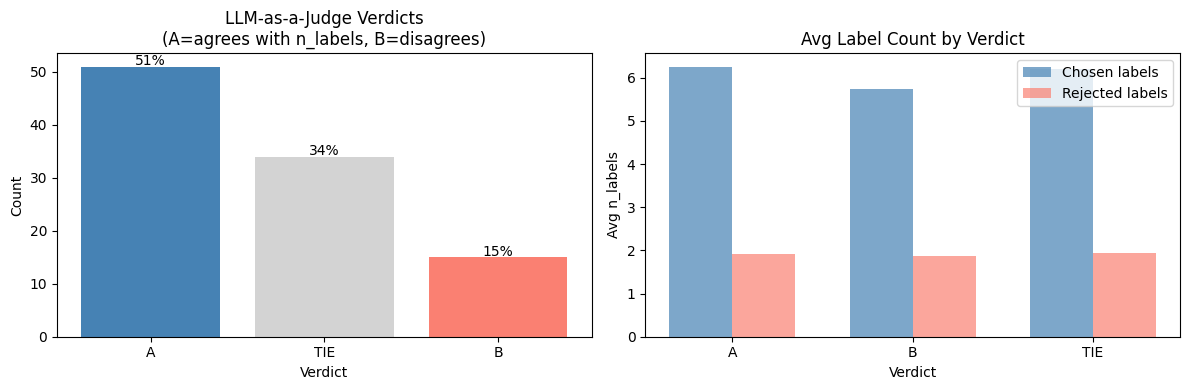

Saved to figures/05_llm_judge.png


In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Verdict distribution
verdict_counts = results_df["verdict"].value_counts()
colors = ['steelblue', 'lightgray', 'salmon']
axes[0].bar(verdict_counts.index, verdict_counts.values, color=colors)
axes[0].set_title('LLM-as-a-Judge Verdicts\n(A=agrees with n_labels, B=disagrees)')
axes[0].set_xlabel('Verdict')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(verdict_counts.items()):
    axes[0].text(i, v + 0.3, f'{v/len(results_df):.0%}', ha='center')

# Label distribution by verdict
verdict_groups = results_df.groupby("verdict")[["chosen_labels", "rejected_labels"]].mean()
x = range(len(verdict_groups))
width = 0.35
axes[1].bar([i - width/2 for i in x], verdict_groups["chosen_labels"], 
            width, label="Chosen labels", color='steelblue', alpha=0.7)
axes[1].bar([i + width/2 for i in x], verdict_groups["rejected_labels"], 
            width, label="Rejected labels", color='salmon', alpha=0.7)
axes[1].set_title('Avg Label Count by Verdict')
axes[1].set_xlabel('Verdict')
axes[1].set_ylabel('Avg n_labels')
axes[1].set_xticks(x)
axes[1].set_xticklabels(verdict_groups.index)
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/05_llm_judge.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to figures/05_llm_judge.png")

## Summary and Implications

| Metric | Value |
|---|---|
| Pairs evaluated | 100 |
| Agreement with n_labels | 51% |
| TIE | 34% |
| Disagreement (Claude prefers rejected) | 15% |

**Conclusion:** n_labels agreement at 51% is statistically indistinguishable from 
chance (50%), confirming it is a weak proxy for legal relevance.

**Production implication:** Replacing n_labels with LLM-as-a-Judge as the preference 
signal would generate higher-quality training data for the reward model, likely 
improving GRPO policy performance beyond the current 64.5% selection accuracy.

**Next step:** Re-train reward model using LLM-as-a-Judge preferences instead of 
n_labels, and compare reward model pairwise accuracy and GRPO selection accuracy.

In [14]:
# Save results
results_df.to_csv("../data/llm_judge_results.csv", index=False)
print("Saved to data/llm_judge_results.csv")

# Summary
print("\n" + "="*50)
print("LLM-AS-A-JUDGE SUMMARY")
print("="*50)
print(f"Pairs evaluated:              {len(results_df)}")
print(f"Agrees with n_labels (A):     {(results_df['verdict']=='A').sum()} ({(results_df['verdict']=='A').mean():.0%})")
print(f"Tie:                          {(results_df['verdict']=='TIE').sum()} ({(results_df['verdict']=='TIE').mean():.0%})")
print(f"Disagrees with n_labels (B):  {(results_df['verdict']=='B').sum()} ({(results_df['verdict']=='B').mean():.0%})")
print(f"\nn_labels agreement rate:      {(results_df['verdict']=='A').mean():.0%} (barely above chance)")
print(f"Implication: LLM-as-a-Judge")
print(f"provides richer preference signal than n_labels proxy")
print("="*50)

Saved to data/llm_judge_results.csv

LLM-AS-A-JUDGE SUMMARY
Pairs evaluated:              100
Agrees with n_labels (A):     51 (51%)
Tie:                          34 (34%)
Disagrees with n_labels (B):  15 (15%)

n_labels agreement rate:      51% (barely above chance)
Implication: LLM-as-a-Judge
provides richer preference signal than n_labels proxy


**Handling TIE verdicts in production:**

34% TIE rate is a known challenge in LLM-as-a-Judge pipelines. Common strategies:

1. **Discard TIEs** — remove ambiguous pairs from training data. With large datasets 
   (100K+ pairs), losing 34% is acceptable and preserves signal quality.
2. **Second opinion** — run a second LLM on TIE cases; discard if both agree on TIE.
3. **Forced choice** — modify prompt to require A or B; risks introducing noise.
4. **Soft labels** — request continuous scores (1-10) instead of A/B/TIE; 
   reward model learns that TIE pairs have small score differences.

For this project, Strategy 1 (discard TIEs) would be the recommended approach,
leaving 66 high-confidence preference pairs per 100 evaluated — sufficient signal
for reward model training at scale.